In [74]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.feature_selection import VarianceThreshold
plt.style.use('ggplot')
pd.set_option('display.max.columns',500)

In [73]:
#pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 101.3 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 94.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


Explonatory Data Analysis: missing values, wrong data type checks , remove duplicates , correct invalid data set.

In [8]:
#data understanding
data = pd.read_csv("/kaggle/input/datasets/oluwanifemiabimbola/frauddetectiondataset/fraudTrain.csv")
data.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [9]:
#random 10 rows of the data to avoid bias
data.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1294089,1294089,2020-06-20 13:56:17,4755696071492,fraud_Cartwright PLC,kids_pets,24.98,Robert,Evans,M,01892 Patricia Vista Apt. 828,Sachse,TX,75048,32.9643,-96.6012,20328,Site engineer,1985-06-20,67460edbe4fb537cbffea3f2a8c4c249,1371736577,33.158906,-96.736587,0
139382,139382,2019-03-17 08:11:16,4260059589824237,fraud_Bins-Rice,gas_transport,61.49,Aaron,Rogers,M,969 Huerta Path Apt. 270,Valentine,NE,69201,42.8062,-100.6215,4005,Network engineer,1945-03-15,84146acd2a334aeb7e4dd557d0ebf788,1331971876,43.219736,-99.985225,0
505167,505167,2019-08-07 11:25:37,4642255475285942,"fraud_Rowe, Batz and Goodwin",grocery_pos,69.34,Sabrina,Johnson,F,320 Nicholson Orchard,Thompson,UT,84540,38.9999,-109.6150,46,"Surveyor, minerals",1987-04-23,bff27f6ad47918f8d55c98c295d8aede,1344338737,39.655923,-110.223869,0
472689,472689,2019-07-27 11:51:36,4992346398065154184,"fraud_Weimann, Kuhic and Beahan",shopping_pos,7.64,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,4fac62ae3043b683f9a29a238fb4d74e,1343389896,40.574589,-88.990512,0
1290502,1290502,2020-06-18 23:38:06,3563837241599446,"fraud_Kihn, Brakus and Goyette",personal_care,163.73,Timothy,Simmons,M,1049 John Ports Suite 057,Newberg,OR,97132,45.3099,-122.9685,28278,Research scientist (physical sciences),1977-07-17,96771a7ed2b1c775f5be1044dc65e6fb,1371598686,45.545684,-122.909182,0
45854,45854,2019-01-28 04:55:44,3596357274378601,fraud_Kutch and Sons,grocery_pos,52.68,David,Everett,M,4138 David Fall,Morrisdale,PA,16858,41.0001,-78.2357,3688,Advice worker,1973-05-27,a5cd6cf82a5f21d742705328a2eab681,1327726544,41.901234,-77.584463,0
147829,147829,2019-03-20 23:07:38,377113842678100,"fraud_Ritchie, Oberbrunner and Cremin",travel,5.23,Billy,Gallagher,M,673 Delgado Burg,Greenwich,NJ,8323,39.4055,-75.3209,804,Insurance risk surveyor,1965-03-25,f1258bdb2fcd1e6761cbe9387154d4d5,1332284858,39.053826,-76.039366,0
506047,506047,2019-08-07 19:33:48,630423337322,fraud_Dare-Gibson,health_fitness,91.57,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,d4dc4a518d03f4a89232ca975b902625,1344368028,49.785755,-117.476762,0
54270,54270,2019-02-02 05:23:23,4989847570577635369,fraud_Padberg-Welch,grocery_pos,194.01,Vanessa,Anderson,F,21178 Brittney Locks,Prosperity,SC,29127,34.1832,-81.5324,8333,Archaeologist,1994-07-09,db5347ba611cde15cf5aba92b79feb7d,1328160203,34.094534,-82.262394,0
438254,438254,2019-07-14 18:04:38,30561214688470,"fraud_Turcotte, McKenzie and Koss",entertainment,47.20,Gina,Morrison,F,41851 Victor Drives Suite 219,Allentown,PA,18103,40.5891,-75.4645,166081,"Scientist, research (maths)",1998-10-01,089f19b8d04ba183974d81d11eb0d616,1342289078,40.826657,-76.204041,0


In [10]:
#checking the missing values and duplicate to avoid high bias in the model
missing_value = data.isna().sum()
duplicate_value = data.duplicated().sum()
print(f'Missing values:{missing_value}')
print(f'Duplicate Value:{duplicate_value}')

Missing values:Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
Duplicate Value:0


In [11]:
#checking the columns,shape rows and column types and describe
data.shape

(1296675, 23)

In [12]:
#the data columns
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [13]:
#make sure the features are in the right format
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [14]:
#more information on the data set
data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


Feature engineering focusing on renaming , removing and creating new features
removing the cc_num as it has scale with large standard deviation as it is on different scale , same with the ID.
feature scaling for the zip, amt and city pop because of high scale value.
create distance features with lat and long,as it reduce dimentionality for simplicity sake for the model

In [15]:
#rename column
data = data.rename(columns={'Unnamed: 0':'ID'})

In [16]:
#confirm the column
data.columns

Index(['ID', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [17]:
#calculating the euclidean distance from a refrence point
ref_lat = data['lat'].mean()
ref_long = data['long'].mean()

data['distance_from_center'] = np.sqrt((data['lat'] - ref_lat) ** 2 + (data['long'] - ref_long)**2)

In [18]:
#drop the exsting lat and long column, drop last and first name
data = data.drop(['last','first'],axis=1)

In [19]:
#randoming checking the datset
data.sample(4)

,ID,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_from_center
53823,53823,2019-02-01 21:32:03,4979422371139333,fraud_Reichel LLC,personal_care,104.96,F,1893 Katie Tunnel,Westerville,NE,68881,41.4193,-99.3844,73,Product designer,1935-02-10,68770f38878a983c863fce1dde19c178,1328131923,42.028019,-100.114355,0,9.600740
557003,557003,2019-08-25 18:38:48,3517527805128735,fraud_Stamm-Rodriguez,misc_pos,2.98,F,6778 Campos Field,Bonfield,IL,60913,41.1573,-88.0619,1617,Medical secretary,1990-04-25,460079fb58aff0cfc2abcf9f3cf1d539,1345919928,42.143296,-87.460875,0,3.398161
701832,701832,2019-10-26 22:53:15,213193596103206,fraud_Weber and Sons,food_dining,55.17,M,7369 Gabriel Tunnel,Pointe Aux Pins,MI,49775,45.7549,-84.4470,95,Electrical engineer,1994-02-09,5f6cd61d5942f5535d30212fd33f1890,1351291995,46.658122,-84.043737,0,9.246071
292784,292784,2019-05-24 08:59:23,3558652751678952,"fraud_Langworth, Boehm and Gulgowski",shopping_net,8.83,F,6638 Lucero Mill Suite 952,Karnack,TX,75661,32.6205,-94.2000,2807,Chiropodist,1931-01-26,3d7d820fef5ac2b91d2314200a54bb8d,1337849963,32.556118,-93.558368,0,7.127576


In [20]:
#checking the data is balanace or not and it is imbalance , we have less of fraud data
data.groupby('is_fraud')['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [21]:
#convert date to year,month,day and into hour, minute and second.
data['transac_date'] = pd.to_datetime(data['trans_date_trans_time'])
data['year'] = data['transac_date'].dt.year
data['month'] = data['transac_date'].dt.month
data['quarter'] = data['transac_date'].dt.quarter
data['dayoftheweek'] = data['transac_date'].dt.day_of_week
data['time'] = data['transac_date'].dt.time
data['hour']= data['transac_date'].dt.hour
data['minute'] = data['transac_date'].dt.minute
data['second'] = data['transac_date'].dt.second

In [22]:
#computing the time since last transaction per customer in seconds
data = data.sort_values('transac_date')
data['time_since_last_transaction'] = (data.groupby('ID')['transac_date']
                                       .diff()
                                       .dt.total_seconds()
                                       .fillna(0)
)

In [23]:
#flagging the rapid transaction potential fraud :
#transaction under 60 seconds apart from the customer are a strong fraud indicator
data['is_rapid_txn'] = (data['time_since_last_transaction']< 60).astype(int)

In [24]:
#extracting the birth year to calculate their age to the time of fraud
data['dob'] = pd.to_datetime(data['dob'])
data['birth_year'] = data['dob'].dt.year
#calculatetheclientage
data['age'] = data['year'] - data['birth_year']

In [25]:
#group the time of the day into broader category like morning ,afternoon,evening,night
def categorize_time_of_day(hour):
    if hour >= 6 and hour <=11:
      return 'Morning'
    elif hour >=12 and hour <= 17:
      return 'Afternoon'
    elif hour >=18 and hour <=23:
      return 'evening'
    else:
      return 'Night'



data['season_of_day'] =data['hour'].apply(categorize_time_of_day)

In [26]:
#group the day of the week into week day and weekends
def group_week_day(dayofw):
  wk_day = [1,2,3,4,5]
  week_end = [0,6]
  if dayofw in wk_day:
    return 'weekday'
  else:
    return 'weekend'


data['time_of_the_week'] = data['dayoftheweek'].apply(group_week_day)


In [27]:
#drop the transac transac column since it has been converted
data = data.drop(['trans_date_trans_time','transac_date'],axis=1)

In [28]:
#drop the date of birth
data = data.drop(['dob','time'],axis=1)

Explonatory Data Analysis(Univariate and Muiltivariate): Understanding the features and the relationship between the features.

Text(0, 0.5, 'Sum of the Age')

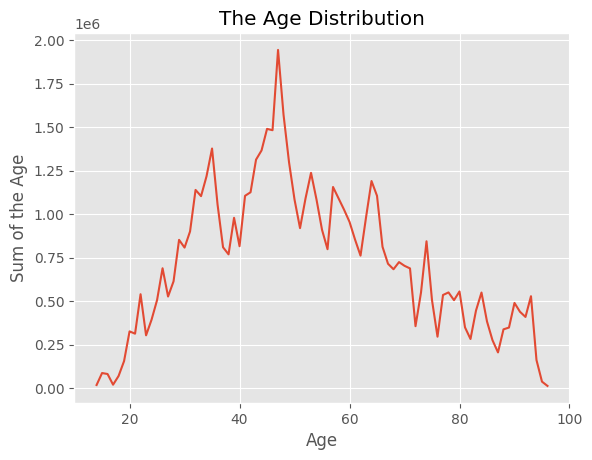

In [29]:
#age group distribution
age_grp = data.groupby('age')['age'].sum()
age_grp.plot(kind='line')
plt.title('The Age Distribution')
plt.xlabel('Age')
plt.ylabel('Sum of the Age')
#plt.xticks(rotation=90)

(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.]),
 [Text(-1.0, 0, '(evening, 1)'),
  Text(0.0, 0, '(Afternoon, 0)'),
  Text(1.0, 0, '(Afternoon, 1)'),
  Text(2.0, 0, '(Morning, 0)'),
  Text(3.0, 0, '(Morning, 1)'),
  Text(4.0, 0, '(Night, 0)'),
  Text(5.0, 0, '(Night, 1)'),
  Text(6.0, 0, '(evening, 0)'),
  Text(7.0, 0, '(evening, 1)'),
  Text(8.0, 0, '')])

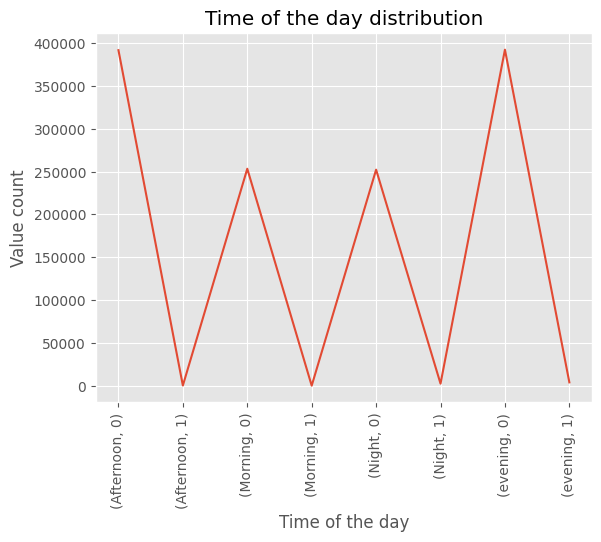

In [30]:
#time of day distribution
time_of_day = data.groupby('season_of_day')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5]),
 [Text(-0.5, 0, ''),
  Text(0.0, 0, '(weekday, 0)'),
  Text(0.5, 0, ''),
  Text(1.0, 0, '(weekday, 1)'),
  Text(1.5, 0, ''),
  Text(2.0, 0, '(weekend, 0)'),
  Text(2.5, 0, ''),
  Text(3.0, 0, '(weekend, 1)'),
  Text(3.5, 0, '')])

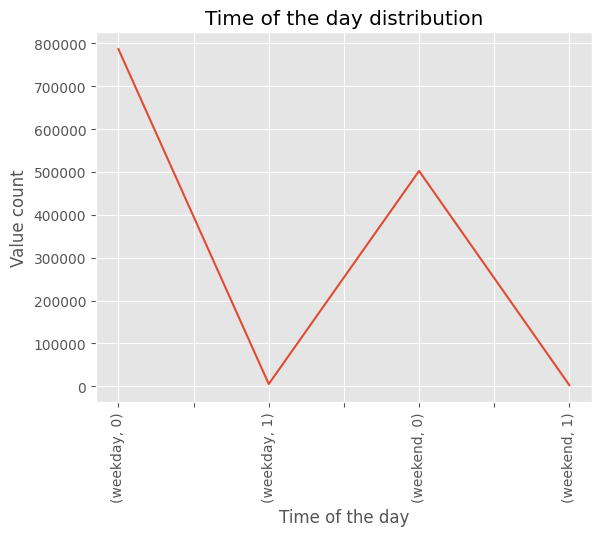

In [31]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

Text(0, 0.5, 'value count')

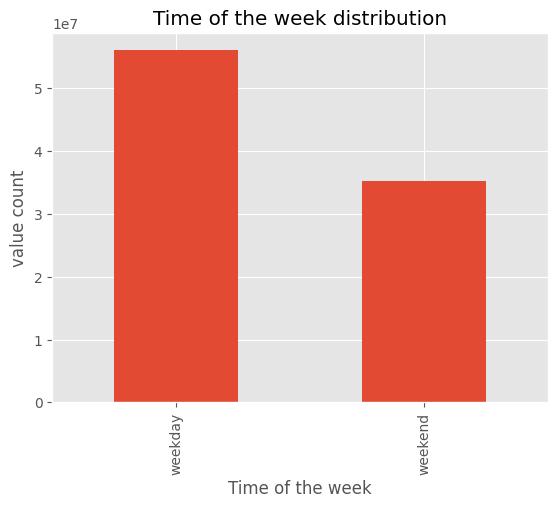

In [32]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['amt'].sum()
time_of_day.plot(kind='bar')
plt.title('Time of the week distribution')
plt.xlabel('Time of the week')
plt.ylabel('value count')
#plt.xticks(rotation=90)

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(-2.0, 0, 'shopping_pos'),
  Text(0.0, 0, 'entertainment'),
  Text(2.0, 0, 'gas_transport'),
  Text(4.0, 0, 'grocery_pos'),
  Text(6.0, 0, 'home'),
  Text(8.0, 0, 'misc_net'),
  Text(10.0, 0, 'personal_care'),
  Text(12.0, 0, 'shopping_pos'),
  Text(14.0, 0, '')])

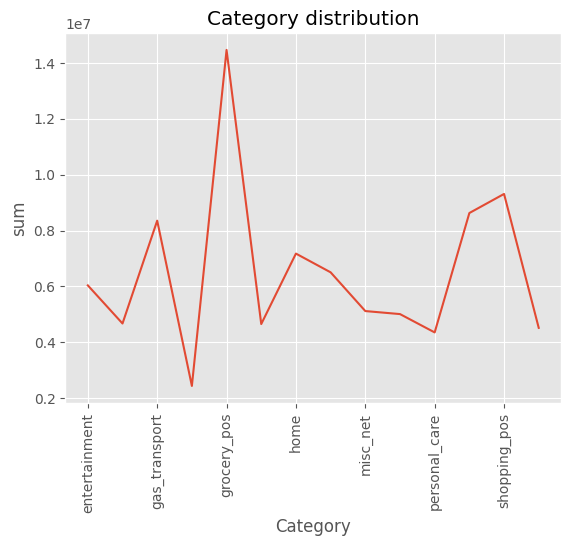

In [33]:
#category distribution
time_of_day = data.groupby('category')['amt'].sum()
time_of_day.plot(kind='line')
plt.title('Category distribution')
plt.xlabel('Category')
plt.ylabel('sum')
plt.xticks(rotation=90)

In [34]:
#merchant distribution in the dataset
data.groupby('merchant')['is_fraud'].value_counts().tail(10)

merchant                          is_fraud
fraud_Zemlak Group                0           1280
                                  1             17
fraud_Zemlak, Tillman and Cremin  0           1802
                                  1              2
fraud_Ziemann-Waters              0           1689
                                  1              6
fraud_Zieme, Bode and Dooley      0           2552
                                  1              8
fraud_Zulauf LLC                  0           1781
                                  1              2
Name: count, dtype: int64

In [35]:
#Category distribution in the dataset
data.groupby('category')['is_fraud'].value_counts()

category        is_fraud
entertainment   0            93781
                1              233
food_dining     0            91310
                1              151
gas_transport   0           131041
                1              618
grocery_net     0            45318
                1              134
grocery_pos     0           121895
                1             1743
health_fitness  0            85746
                1              133
home            0           122917
                1              198
kids_pets       0           112796
                1              239
misc_net        0            62372
                1              915
misc_pos        0            79405
                1              250
personal_care   0            90538
                1              220
shopping_net    0            95830
                1             1713
shopping_pos    0           115829
                1              843
travel          0            40391
                1             

In [36]:
# the distribution of age with fraud
data.groupby('age')['is_fraud'].value_counts().sample(10)

age  is_fraud
85   1              35
38   0           20105
68   0           10038
30   0           26752
87   0            2320
67   0           10580
31   0           28968
20   1              93
63   1             109
     0           15456
Name: count, dtype: int64

In [37]:
#gender distribution
data.groupby('gender')['is_fraud'].value_counts()

gender  is_fraud
F       0           706128
        1             3735
M       0           583041
        1             3771
Name: count, dtype: int64

<Axes: title={'center': 'the difference in the gender distribution'}, xlabel='gender'>

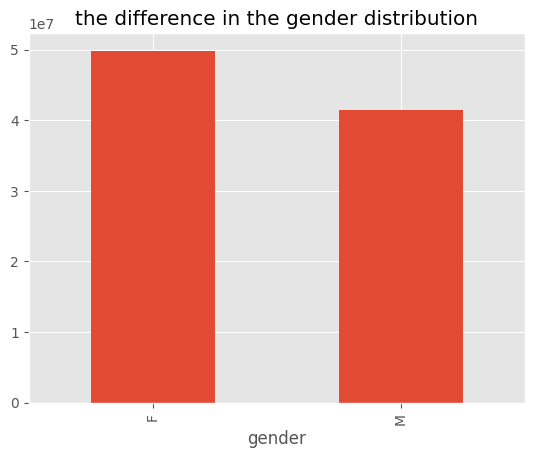

In [38]:
#plotting the distribution of data among the gender
gender_dist = data.groupby('gender')['amt'].sum()
gender_dist.plot(kind='bar',title='the difference in the gender distribution')

<Axes: xlabel='is_fraud'>

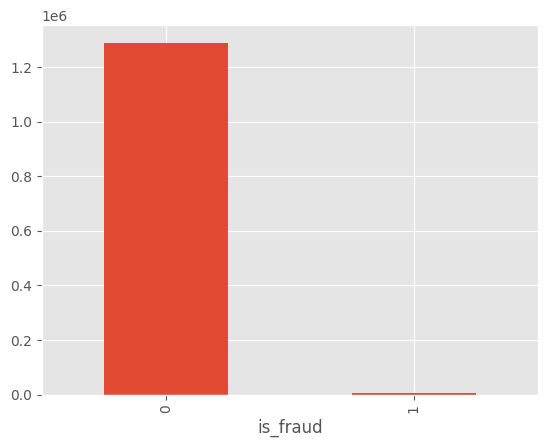

In [39]:
#the fraud dataset distribution
fraud_distribution = data.groupby('is_fraud')['is_fraud'].value_counts()
fraud_distribution.plot(kind='bar')

In [40]:
#correlation for the features relationship
#Extracting the numeric data
numerical_cos = data.select_dtypes(include=[np.number])
numerical_cos.corr()

,ID,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,distance_from_center,year,month,quarter,dayoftheweek,hour,minute,second,time_since_last_transaction,is_rapid_txn,birth_year,age
ID,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767,-0.001126,0.783311,0.181956,0.151242,-0.030910,0.001073,0.000030,0.000174,NaN,NaN,0.003736,0.016644
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,0.053220,0.000466,-0.000281,-0.000465,-0.002481,-0.000801,0.000812,0.000036,NaN,NaN,0.000291,-0.000279
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,0.002640,0.000842,-0.001748,-0.001962,-0.001001,-0.022811,0.000383,0.001405,NaN,NaN,0.009748,-0.009724
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.227925,0.000086,0.000852,0.000500,-0.001353,0.005938,0.000766,0.000127,NaN,NaN,-0.011004,0.011004
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,0.185967,0.001274,-0.001072,-0.001342,0.000498,-0.011508,-0.000243,-0.000221,NaN,NaN,-0.047845,0.047868
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.519266,0.000191,-0.001213,-0.000697,0.001593,-0.002290,-0.000825,0.000325,NaN,NaN,0.030231,-0.030220
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,0.056586,-0.001673,0.000137,-0.000280,0.002439,0.020381,-0.000713,0.000690,NaN,NaN,0.091271,-0.091295
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,-0.001145,0.782582,0.184868,0.153618,-0.029284,0.000756,0.000006,0.000191,NaN,NaN,0.003655,0.016707
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,0.184745,0.001244,-0.001116,-0.001428,0.000263,-0.011378,-0.000217,-0.000281,NaN,NaN,-0.047458,0.047480
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.518812,0.000184,-0.001197,-0.000688,0.001553,-0.002325,-0.000820,0.000310,NaN,NaN,0.030154,-0.030142


In [41]:
#checking the skewness of the numeric data
#ignoring the skew data , since its random forest model
numerical_cos.skew()

ID                             1.233496e-16
cc_num                         2.851879e+00
amt                            4.227787e+01
zip                            7.968076e-02
lat                           -1.860277e-01
long                          -1.150108e+00
city_pop                       5.593853e+00
unix_time                      3.377950e-03
merch_lat                     -1.819154e-01
merch_long                    -1.146960e+00
is_fraud                       1.302912e+01
distance_from_center           2.245465e+00
year                           9.430622e-01
month                          2.985158e-01
quarter                        2.585613e-01
dayoftheweek                  -7.845304e-02
hour                          -2.828255e-01
minute                        -3.937129e-04
second                        -6.966114e-04
time_since_last_transaction    0.000000e+00
is_rapid_txn                   0.000000e+00
birth_year                    -6.123585e-01
age                            6

In [42]:
#remove ccnum and id
data = data.drop(columns=['cc_num','ID','unix_time','birth_year'], axis=1)

In [43]:
#the function to calculate the difference in the target value
def percentage_increase(fra,not_frad):
    percentage_difference_fra = round((fra/(fra + not_frad)) * 100, 2)
    percentage_difference_not_frad = round((not_frad/(fra + not_frad)) *100,2)
    return (f'fraud:{percentage_difference_fra}, Not Fraud:{percentage_difference_not_frad}')


fra = data['is_fraud'].value_counts()[1]
not_frad = data['is_fraud'].value_counts()[0]

percentage_increase(fra,not_frad)



'fraud:0.58, Not Fraud:99.42'

<Axes: ylabel='Frequency'>

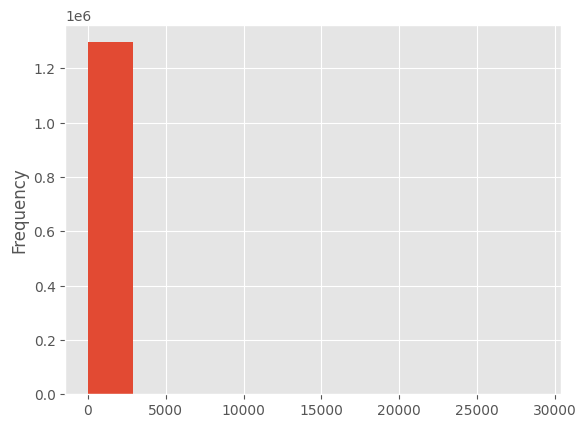

In [44]:
#amt distribution, shows the data is highly right skewed
data['amt'].plot(kind='hist')

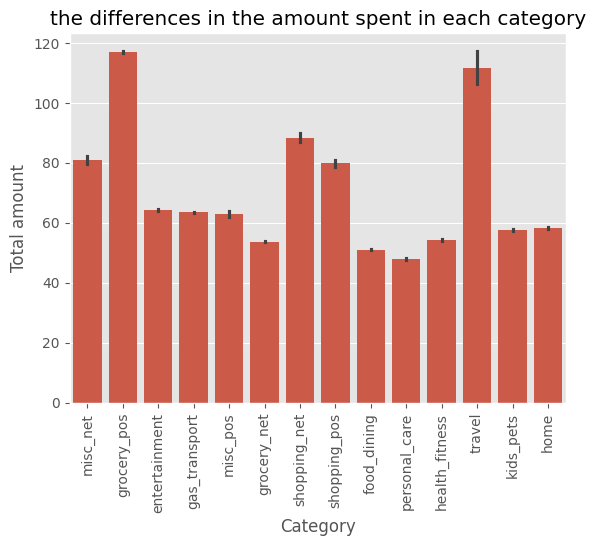

In [45]:
#category amount distribution
sns.barplot(data=data, x='category', y='amt')
plt.title('the differences in the amount spent in each category')
plt.xlabel('Category')
plt.ylabel('Total amount')
plt.xticks(rotation=90)
plt.show()

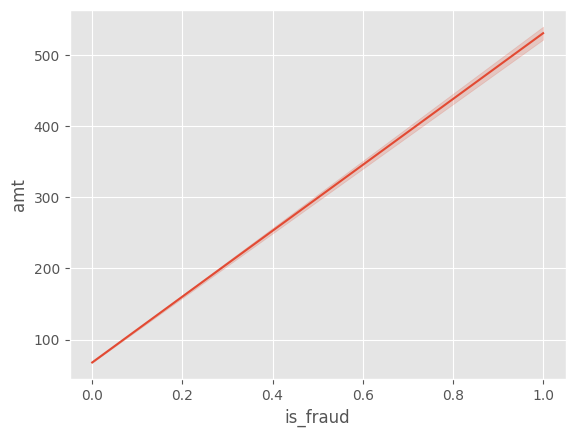

In [46]:
#there is so much outlier in is not fraud features
sns.lineplot(data=data,x='is_fraud', y='amt')

plt.show()

Splitting of the dataset into Train and Test set

In [47]:
#splitting data into input and output
X = data.drop(['is_fraud'], axis = 1)
y = data['is_fraud']

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

Encoding the categorical data: For the test data we use the transform while the train data we use the fit. It is best to encode the dataset after split to avoid data leakeage.


In [49]:
#Extracting the numeric data
numerical_columns = X_train.select_dtypes(include=[np.number])
numerical_columns.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
       'distance_from_center', 'year', 'month', 'quarter', 'dayoftheweek',
       'hour', 'minute', 'second', 'time_since_last_transaction',
       'is_rapid_txn', 'age'],
      dtype='object')

In [50]:
#extracting the categorical data
categorical_columns = X_train.select_dtypes(include=['object'])
categorical_columns.columns

Index(['merchant', 'category', 'gender', 'street', 'city', 'state', 'job',
       'trans_num', 'season_of_day', 'time_of_the_week'],
      dtype='object')

In [51]:
#for columns like month minute,hour,day of the week, second we need cyclical encoding,
 #but since it is random forest we will leave it' cyclical encoding does not have any significant
 #on tree models. but we keep it for other models


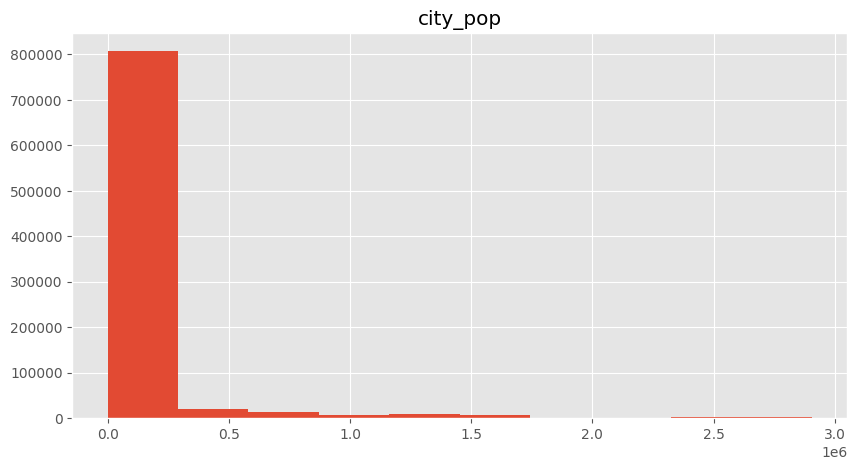

In [52]:
#for columns like city population, citypop log transform
#performing log transform on city population because it on a larger scale value,
#highly skewed and it has zero or and no negative value.
#histogram to show the city_pop
X_train[['city_pop']].hist(figsize=(10,5))
plt.show()



In [53]:
#step 2 to fit the transformation
logt = LogTransformer(variables = ['city_pop'])
logt.fit(X_train)
train_t = logt.transform(X_train)
test_t = logt.transform(X_test)

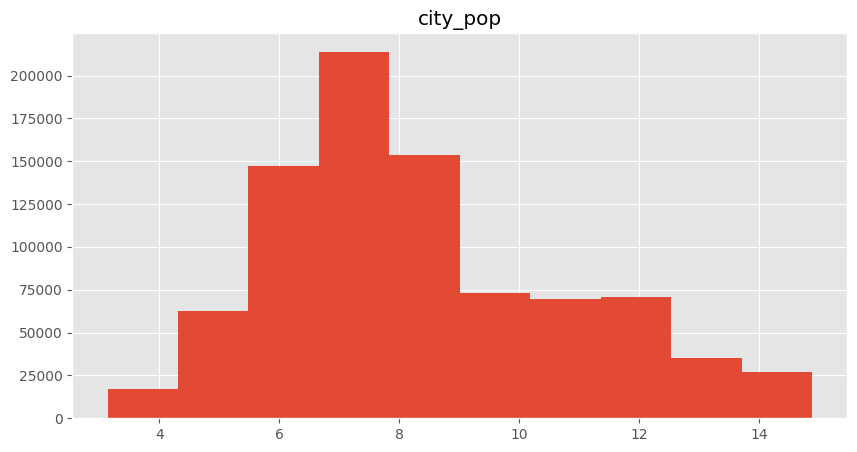

In [54]:
#step3 to check the histogram distribution of the data
train_t[['city_pop']].hist(figsize=(10,5))
plt.show()

In [55]:
# #for columns like zip, merchant,job,transnum,category,street, city, state,frequency encoder:
# #frequency encoder works by replacing values base on the number or percentage of times they appear.
# #convert zip to categorical data
train_t['zip'] = train_t['zip'].astype(str)
test_t['zip'] = test_t['zip'].astype(str)

In [56]:
#part 2 of encoding the features using frequency encoder
#zip, merchant,job,transnum,category,street, city, state
encoder = CountFrequencyEncoder(encoding_method='frequency',
                                variables=['merchant','zip','job','trans_num',
                                           'category','street','city','state'],
)

encoder.fit(train_t)

,encoding_method,'frequency'
,variables,"['merchant', 'zip', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'


In [57]:
#fit the transform on the training and test data
X_train = encoder.transform(train_t)
X_test = encoder.transform(test_t)

print(X_train.head())

         merchant  category     amt gender    street      city     state  \
741541   0.001951  0.095594  105.99      M  0.000393  0.000393  0.043324   
268287   0.001803  0.095024   12.25      M  0.001165  0.001165  0.020744   
1175073  0.000691  0.034915   47.63      F  0.001204  0.001204  0.035663   
1252348  0.001789  0.087136  157.54      F  0.001662  0.001662  0.064611   
815516   0.001910  0.095594  110.70      M  0.000821  0.000821  0.009113   

              zip      lat      long  city_pop       job  trans_num  \
741541   0.000393  34.2980 -114.1560  4.836282  0.000393   0.000001   
268287   0.001165  41.2001  -92.1354  6.342121  0.002357   0.000001   
1175073  0.001204  42.3703  -84.2485  7.833204  0.001204   0.000001   
1252348  0.001662  43.2237  -75.1612  7.428927  0.005985   0.000001   
815516   0.000821  45.1939 -112.0568  5.655992  0.000828   0.000001   

         merch_lat  merch_long  distance_from_center  year  month  quarter  \
741541   33.817199 -115.003550        

/benchmarks/.venv/lib/python3.11/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) trans_num.
  warnings.warn(


In [58]:
#dropping the transaction number
X_test = X_test.drop('trans_num',axis=1)
X_train = X_train.drop('trans_num',axis=1)

In [59]:
#for columns like gender,  'time_of_the_week' binary encoder
#fit into the train set and transform on both train and test set
binary_encoder = ce.BinaryEncoder(cols=['gender','time_of_the_week'],
                                  return_df=True)
#fit the transform on the training and test data
binary_encoder.fit(X_train)
X_train = binary_encoder.transform(X_train)
X_test = binary_encoder.transform(X_test)

print(X_train.head())

         merchant  category     amt  gender_0  gender_1    street      city  \
741541   0.001951  0.095594  105.99         0         1  0.000393  0.000393   
268287   0.001803  0.095024   12.25         0         1  0.001165  0.001165   
1175073  0.000691  0.034915   47.63         1         0  0.001204  0.001204   
1252348  0.001789  0.087136  157.54         1         0  0.001662  0.001662   
815516   0.001910  0.095594  110.70         0         1  0.000821  0.000821   

            state       zip      lat      long  city_pop       job  merch_lat  \
741541   0.043324  0.000393  34.2980 -114.1560  4.836282  0.000393  33.817199   
268287   0.020744  0.001165  41.2001  -92.1354  6.342121  0.002357  41.764939   
1175073  0.035663  0.001204  42.3703  -84.2485  7.833204  0.001204  43.256029   
1252348  0.064611  0.001662  43.2237  -75.1612  7.428927  0.005985  43.311113   
815516   0.009113  0.000821  45.1939 -112.0568  5.655992  0.000828  45.830128   

         merch_long  distance_from_cen

In [60]:
#checking the cardinality of the variable
X_train[['season_of_day']].nunique()

season_of_day    4
dtype: int64

In [61]:
# for the 'season_of_day', one hot encoding
one_hot_encoder = OneHotEncoder(
    variables=['season_of_day'],
    drop_last=True,
    )

one_hot_encoder.fit(X_train)

,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['season_of_day']
,ignore_format,False


In [62]:
X_train = one_hot_encoder.transform(X_train)
X_test = one_hot_encoder.transform(X_test)

print(X_train.head())

         merchant  category     amt  gender_0  gender_1    street      city  \
741541   0.001951  0.095594  105.99         0         1  0.000393  0.000393   
268287   0.001803  0.095024   12.25         0         1  0.001165  0.001165   
1175073  0.000691  0.034915   47.63         1         0  0.001204  0.001204   
1252348  0.001789  0.087136  157.54         1         0  0.001662  0.001662   
815516   0.001910  0.095594  110.70         0         1  0.000821  0.000821   

            state       zip      lat      long  city_pop       job  merch_lat  \
741541   0.043324  0.000393  34.2980 -114.1560  4.836282  0.000393  33.817199   
268287   0.020744  0.001165  41.2001  -92.1354  6.342121  0.002357  41.764939   
1175073  0.035663  0.001204  42.3703  -84.2485  7.833204  0.001204  43.256029   
1252348  0.064611  0.001662  43.2237  -75.1612  7.428927  0.005985  43.311113   
815516   0.009113  0.000821  45.1939 -112.0568  5.655992  0.000828  45.830128   

         merch_long  distance_from_cen

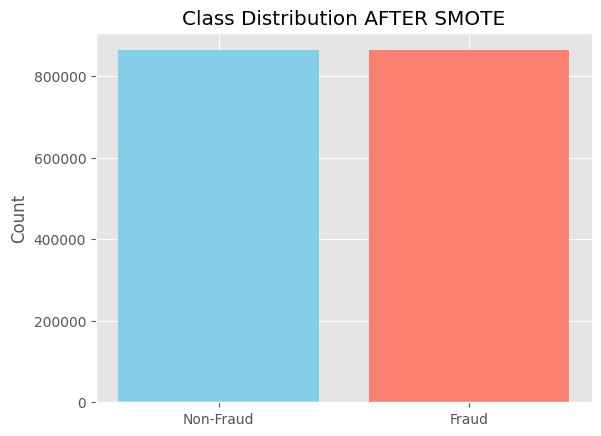

In [63]:
#ignoring the skewness and outlier for random forest
#Imbalance dataset
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [64]:
#variance threshold 
# Sample first to speed it up
X_sample = X_train_sm.sample(frac=0.1, random_state=42)

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_sample)

variance_df = pd.DataFrame({
'feature': X_sample.columns.tolist(),
'variance': selector.variances_
}).sort_values('variance', ascending=True)

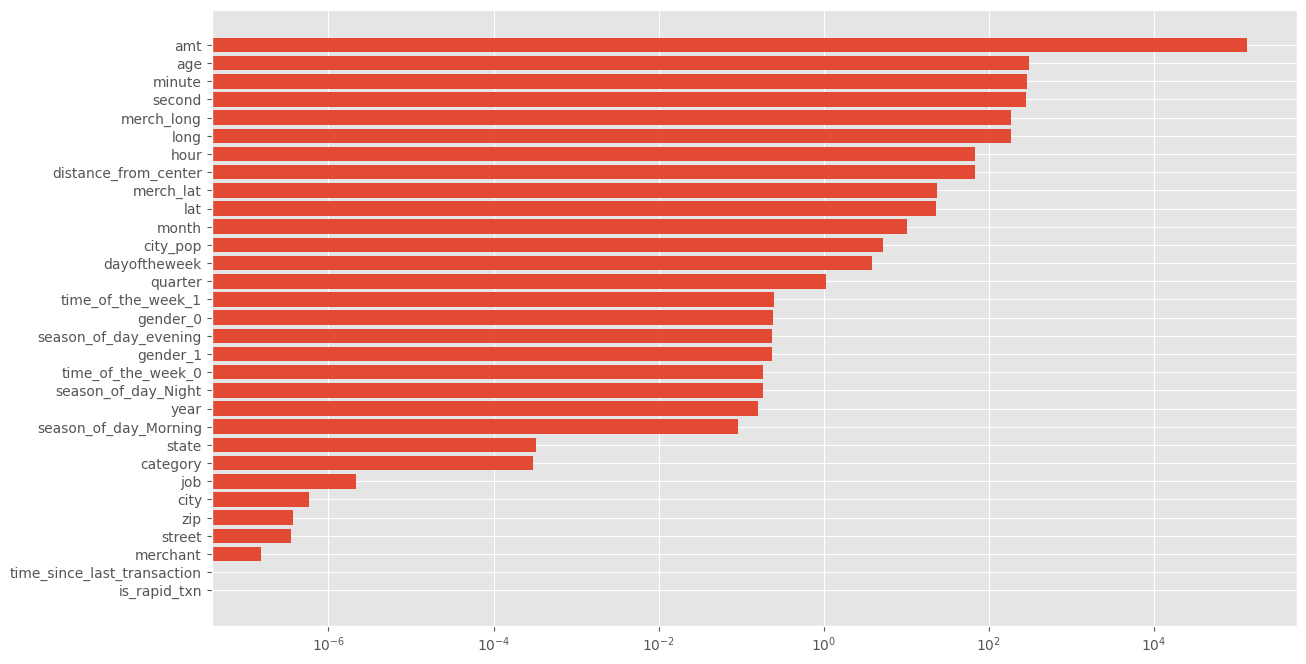

In [65]:
#variance threshold 
plt.figure(figsize=(14,8))

plt.barh(variance_df['feature'],variance_df['variance'])
plt.xscale('log')
plt.show()

In [66]:
X_train_sm.columns

Index(['merchant', 'category', 'amt', 'gender_0', 'gender_1', 'street', 'city',
       'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'month', 'quarter',
       'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age',
       'time_of_the_week_0', 'time_of_the_week_1', 'season_of_day_Night',
       'season_of_day_evening', 'season_of_day_Morning'],
      dtype='object')

In [67]:
# #remove the last features for variance threshold
# X_train_sm = X_train_sm.drop(['time_since_last_transaction','is_rapid_txn',
#                               'merchant','street','zip'],axis =1)
#X_test= X_test.drop(['time_since_last_transaction','is_rapid_txn',
                   #   'merchant','street','zip'],axis =1)

IndentationError: unexpected indent (3090471224.py, line 5)

In [ ]:
#hyperparameter tuning using the gridsearch
estimators = RandomForestClassifier()
# Define hyperparameter distributions
param_dist = {
    'n_estimators': [50,100,200],
    'max_features': ['sqrt'],
    'max_depth': [5,10,15,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf':[1,2,4],
    'bootstrap': [True, False]
}

In [ ]:
# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator= estimators,
    param_distributions=param_dist,
    n_iter=5,  # Number of parameter settings that are sampled
    cv=3,  # Number of cross-validation folds
    verbose=2,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1  # Use all available processors
)

In [ ]:
# 1. Fit the RandomizedSearchCV object
random_search.fit(X_train_sm, y_train_sm)

# 2. Access the attributes
best_parameters = random_search.best_params_
print(best_parameters)

In [ ]:
#fitting random forest
model = RandomForestClassifier(max_depth=20,
                               min_samples_split = 5,
                               min_samples_leaf= 2,
                               n_estimators = 50,
                               max_features= 'sqrt',
                               class_weight = 'balanced',
                               random_state=42)
model.fit(X_train_sm,y_train_sm)

In [ ]:
#model metrics
y_pred_sm = model.predict(X_test)
print("Accuracy AFTER SMOTE:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

In [ ]:
#lowering the model threshold for threshold optimisation
y_prob = model.predict_proba(X_test)[:,1]
y_pred_adjusted = (y_prob >= 0.5).astype(int)
#lower threshold catches more fraud
print(classification_report(y_test,y_pred_adjusted))

In [ ]:
#confusion matrics graph
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#improving the model precision by using shap to understand the feature ,
#hyperparameter tuning ,more feature engineering,threshold tuning,resampling
#using shap for 500 rows , since the data is large
X_test_sample = X_test.sample(500,random_state=42)
# Fits the explainer
explainer = shap.TreeExplainer(model)

In [ ]:
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test_sample)

In [ ]:
# Get mean absolute SHAP values
vals = np.abs(shap_values.values[:,:,1]).mean(axis=0)
feature_names = X_test_sample.columns.tolist()

# Create dataframe and sort
shap_df = pd.DataFrame({
'feature': feature_names,
'importance': vals
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(shap_df['feature'], shap_df['importance'])
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()